# ES Calendar Spread Strategy — Results Dashboard

**Train (IS):** W1 ESU4→ESZ4 (Sep-24) · W2 ESZ4→ESH5 (Dec-24)  
**Test (OOS):** W3 ESH5→ESM5 (Mar-25) · W4 ESM5→ESU5 (Jun-25)  

| Parameter | Value |
|---|---|
| Signal | z-score ±2.5σ on 10-min rolling FV deviation |
| Standard layers | 90% @ +0.50 pts → SL to BE; 10% @ +0.75 pts |
| Low-z exit | \|entry_z\| < 2.0 → 100% @ +0.25 pts |
| HC add-on | \|z_fill\| > 3.0 + \|z[T+2]\| > 3.0 → double lots at T+2 |
| TC | $8.04/lot round-trip (zero slippage, limit-order fills) |
| Lot basis | 10 lots (gross_usd = per-lot-equivalent) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as spstats

# ── Paths & constants ─────────────────────────────────────────────────────────
RESULTS = Path('/Users/stark/Desktop/Projects/Futures_RollOver/results')
TC      = 8.04
N_LOTS  = 10
np.random.seed(42)

WINDOWS = {
    'W1': ('ESU4_ESZ4_20240912', 'ESU4→ESZ4', 'Sep-24', 'IS'),
    'W2': ('ESZ4_ESH5_20241212', 'ESZ4→ESH5', 'Dec-24', 'IS'),
    'W3': ('ESH5_ESM5_20250313', 'ESH5→ESM5', 'Mar-25', 'OOS'),
    'W4': ('ESM5_ESU5_20250612', 'ESM5→ESU5', 'Jun-25', 'OOS'),
}
SESSIONS  = ['European', 'US_RTH', 'Post_close']
GATES     = ['Baseline', 'V1']
IS_WINS   = ['W1', 'W2']
OOS_WINS  = ['W3', 'W4']

# ── Colour palette ────────────────────────────────────────────────────────────
NAVY   = '#0d1b2a'
STEEL  = '#2471a3'
TEAL   = '#148f77'
GREEN  = '#1e8449'
RED    = '#c0392b'
ORANGE = '#e67e22'
GOLD   = '#f1c40f'
PURPLE = '#7d3c98'
LGRAY  = '#f4f6f7'
MGRAY  = '#aab7b8'
DGRAY  = '#4d5656'

C_IS    = STEEL
C_OOS   = TEAL
C_BASE  = NAVY
C_V1    = ORANGE
C_LONG  = STEEL
C_SHORT = RED
C_WIN   = GREEN
C_LOSS  = RED

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   LGRAY,
    'axes.edgecolor':   MGRAY,
    'axes.labelcolor':  DGRAY,
    'axes.titleweight': 'bold',
    'axes.titlesize':   11,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'legend.fontsize':  8,
    'legend.framealpha': 0.9,
    'font.family':      'sans-serif',
})

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Data loading helpers ──────────────────────────────────────────────────────

def load(wdir, label):
    p = RESULTS / wdir / label / 'trades.parquet'
    if not p.exists(): return pd.DataFrame()
    df = pd.read_parquet(p)
    return df if not df.empty else pd.DataFrame()

def pool(wkeys, label):
    parts = []
    for wk in wkeys:
        wdir = WINDOWS[wk][0]
        df   = load(wdir, label)
        if not df.empty:
            df = df.copy(); df['window'] = wk; df['split'] = WINDOWS[wk][3]
            parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def stats(df):
    if df.empty: return {}
    g = df['gross_usd']; n_val = g - TC
    wins = g[g > 0]; loss = g[g <= 0]
    pf   = wins.sum() / abs(loss.sum()) if len(loss) and loss.sum() != 0 else np.inf
    t, p = spstats.ttest_1samp(n_val, 0.0)
    ci   = spstats.t.interval(0.95, df=len(n_val)-1, loc=n_val.mean(), scale=n_val.sem()) if len(n_val)>1 else (np.nan, np.nan)
    sh   = n_val.mean() / n_val.std() if n_val.std() > 0 else 0
    cum  = g.cumsum()
    mdd  = (cum - cum.cummax()).min()
    return dict(
        n=len(df), wr=(g>0).mean()*100, avg_g=g.mean(), tot_g=g.sum(),
        avg_n=n_val.mean(), tot_n=n_val.sum(), pf=pf,
        sharpe=sh, t=t, p=p, ci_lo=ci[0], ci_hi=ci[1],
        mdd=mdd, mdd_10=mdd*N_LOTS,
        tp_pct=(df['exit_type']=='TP').mean()*100,
        sl_pct=(df['exit_type']=='SL').mean()*100,
        eod_pct=(df['exit_type']=='EOD').mean()*100,
        long_n=(df['direction']==1).sum(), short_n=(df['direction']==-1).sum(),
        long_avg=g[df['direction']==1].mean() if (df['direction']==1).any() else np.nan,
        short_avg=g[df['direction']==-1].mean() if (df['direction']==-1).any() else np.nan,
        hc_n=int(df['hc_addon'].sum()) if 'hc_addon' in df.columns else 0,
    )

def sig_label(p):
    if np.isnan(p): return ''
    return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''

# ── Pre-compute all session×split stats ──────────────────────────────────────
ALL_LABELS = [f'{s}_{g}' for s in SESSIONS for g in GATES]
ss = {}  # (label, split) → stats dict
for lbl in ALL_LABELS:
    for split, wkeys in [('IS', IS_WINS), ('OOS', OOS_WINS), ('ALL', list(WINDOWS))]:
        df = pool(wkeys, lbl)
        s  = stats(df)
        if s: ss[(lbl, split)] = s

print(f'Stats computed for {len(ss)} session×split combos ✓')

Stats computed for 18 session×split combos ✓


---
## 1 · Portfolio Equity Curves
Cumulative net P&L (×10 lots) across all three sessions, sorted by entry time. IS windows shaded blue, OOS windows shaded green.

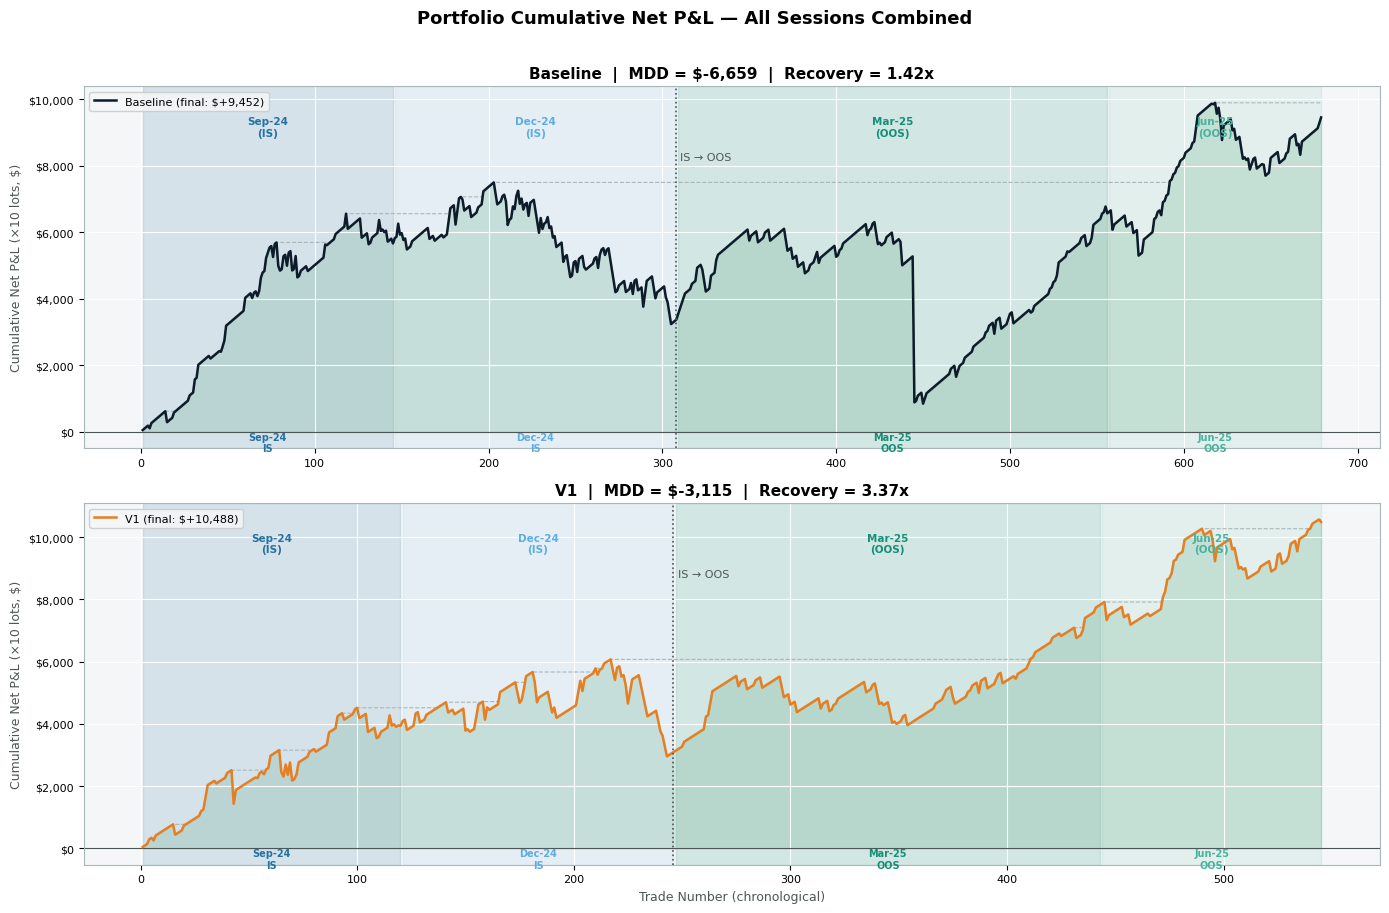

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

SPLIT_COLORS = {'W1': C_IS, 'W2': '#5dade2', 'W3': C_OOS, 'W4': '#45b39d'}
SPLIT_ALPHA  = {'W1': 0.15, 'W2': 0.10, 'W3': 0.15, 'W4': 0.10}

for ax_idx, (gate, ax) in enumerate(zip(GATES, axes)):
    labels_g = [f'{s}_{gate}' for s in SESSIONS]
    port_parts = []
    for wk, (wdir, wlabel, period, split) in WINDOWS.items():
        for lbl in labels_g:
            df = load(wdir, lbl)
            if not df.empty:
                df = df.copy(); df['window'] = wk; df['split'] = split
                port_parts.append(df)
    if not port_parts: continue
    port = pd.concat(port_parts, ignore_index=True).sort_values('entry_time').reset_index(drop=True)
    port['net'] = (port['gross_usd'] - TC) * N_LOTS
    port['cum_net'] = port['net'].cumsum()
    port['peak']    = port['cum_net'].cummax()
    port['dd']      = port['cum_net'] - port['peak']
    port['trade_num'] = np.arange(1, len(port)+1)

    # Shade window regions
    for wk in WINDOWS:
        wmask = port['window'] == wk
        if wmask.any():
            x0 = port.loc[wmask, 'trade_num'].iloc[0]
            x1 = port.loc[wmask, 'trade_num'].iloc[-1]
            ax.axvspan(x0, x1, color=SPLIT_COLORS[wk], alpha=SPLIT_ALPHA[wk], zorder=0)
            mid = (x0 + x1) / 2
            ax.text(mid, ax.get_ylim()[1] if ax_idx==0 else ax.get_ylim()[0],
                    f"{WINDOWS[wk][2]}\n{'IS' if WINDOWS[wk][3]=='IS' else 'OOS'}",
                    ha='center', va='top', fontsize=7, color=SPLIT_COLORS[wk],
                    fontweight='bold')

    ax.fill_between(port['trade_num'], port['dd']*0, port['cum_net'],
                    where=port['cum_net'] >= 0, alpha=0.15, color=GREEN, zorder=1)
    ax.fill_between(port['trade_num'], port['dd']*0, port['cum_net'],
                    where=port['cum_net'] < 0, alpha=0.15, color=RED, zorder=1)
    ax.plot(port['trade_num'], port['cum_net'], color=C_BASE if gate=='Baseline' else C_V1,
            lw=1.8, zorder=3, label=f'{gate} (final: ${port["cum_net"].iloc[-1]:+,.0f})')
    ax.plot(port['trade_num'], port['peak'], color=MGRAY, lw=0.8, ls='--', zorder=2)

    # IS/OOS divider
    is_end = port[port['split']=='IS']['trade_num'].max()
    ax.axvline(is_end, color=DGRAY, lw=1.2, ls=':', zorder=4)
    ax.text(is_end+2, port['cum_net'].max()*0.85, 'IS → OOS', fontsize=8,
            color=DGRAY, va='top')

    mdd = port['dd'].min()
    ax.axhline(0, color=DGRAY, lw=0.8, ls='-')
    ax.set_title(f'{gate}  |  MDD = ${mdd:,.0f}  |  '
                 f'Recovery = {port["cum_net"].iloc[-1]/(abs(mdd)+1e-6):.2f}x',
                 fontsize=11)
    ax.set_ylabel('Cumulative Net P&L (×10 lots, $)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(True, zorder=0)
    ax.legend(loc='upper left')

    # Annotate window boundaries after drawing
    for wk in WINDOWS:
        wmask = port['window'] == wk
        if wmask.any():
            x0 = port.loc[wmask, 'trade_num'].iloc[0]
            x1 = port.loc[wmask, 'trade_num'].iloc[-1]
            mid = (x0 + x1) / 2
            ypos = port['cum_net'].max() * 0.96
            ax.text(mid, ypos, f"{WINDOWS[wk][2]}\n({'IS' if WINDOWS[wk][3]=='IS' else 'OOS'})",
                    ha='center', va='top', fontsize=7.5, color=SPLIT_COLORS[wk],
                    fontweight='bold')

axes[-1].set_xlabel('Trade Number (chronological)')
fig.suptitle('Portfolio Cumulative Net P&L — All Sessions Combined', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · IS vs OOS: Session Performance Comparison
Each bar is avg_net/lot. CI bars are 95% per-trade t-interval. Significance stars: * p<0.10, ** p<0.05, *** p<0.01.

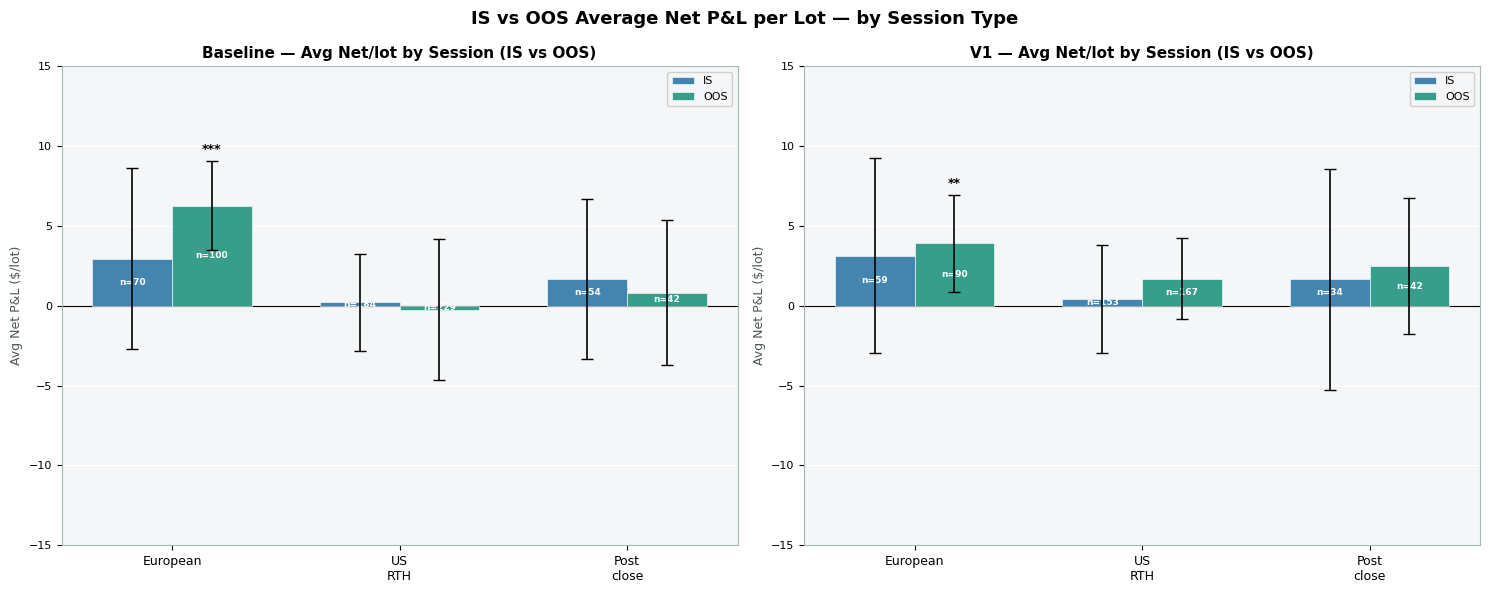

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

for ax, gate in zip(axes, GATES):
    labels_g = [f'{s}_{gate}' for s in SESSIONS]
    x        = np.arange(len(labels_g))
    w        = 0.35

    for i, (split, offset, color) in enumerate([('IS', -w/2, C_IS), ('OOS', w/2, C_OOS)]):
        avgs, errs_lo, errs_hi, ps, ns = [], [], [], [], []
        for lbl in labels_g:
            s = ss.get((lbl, split), {})
            if not s:
                avgs.append(0); errs_lo.append(0); errs_hi.append(0)
                ps.append(1); ns.append(0)
                continue
            avgs.append(s['avg_n'])
            errs_lo.append(s['avg_n'] - s['ci_lo'])
            errs_hi.append(s['ci_hi'] - s['avg_n'])
            ps.append(s['p']); ns.append(s['n'])

        bars = ax.bar(x + offset, avgs, w, color=color, alpha=0.85,
                      label=split, zorder=3, edgecolor='white', lw=0.5)
        ax.errorbar(x + offset, avgs,
                    yerr=[errs_lo, errs_hi],
                    fmt='none', color='black', capsize=4, lw=1.2, zorder=4)

        for xi, (avg, p, n) in enumerate(zip(avgs, ps, ns)):
            stars = sig_label(p)
            ypos  = avg + (errs_hi[xi] if avg >= 0 else -errs_lo[xi]) + 0.3
            if stars:
                ax.text(xi + offset, ypos, stars, ha='center', va='bottom',
                        fontsize=9, fontweight='bold', color='black')
            ax.text(xi + offset, avg/2, f'n={n}', ha='center', va='center',
                    fontsize=6.5, color='white', fontweight='bold')

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('_', '\n') for s in SESSIONS], fontsize=9)
    ax.set_ylabel('Avg Net P&L ($/lot)')
    ax.set_title(f'{gate} — Avg Net/lot by Session (IS vs OOS)')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', zorder=0)
    ax.set_ylim(min(-15, min(avgs)-3), max(15, max(avgs)+5))

fig.suptitle('IS vs OOS Average Net P&L per Lot — by Session Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3 · IS → OOS Rank Preservation
Each dot is one session×gate combination. A perfect strategy preserves the IS ranking in OOS.

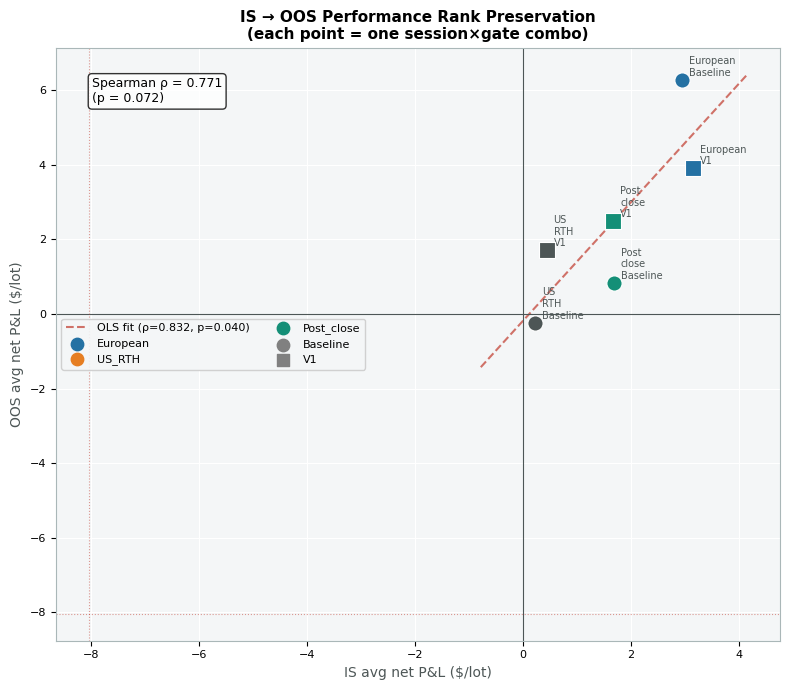

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

sess_colors = {'European': STEEL, 'US_RTH': ORANGE, 'Post_close': TEAL}
gate_markers = {'Baseline': 'o', 'V1': 's'}

is_nets, oos_nets, labels_plot = [], [], []

for lbl in ALL_LABELS:
    s_is  = ss.get((lbl, 'IS'), {})
    s_oos = ss.get((lbl, 'OOS'), {})
    if not s_is or not s_oos: continue
    is_nets.append(s_is['avg_n'])
    oos_nets.append(s_oos['avg_n'])
    labels_plot.append(lbl)

    sess = lbl.split('_')[0] if 'close' not in lbl else 'Post_close'
    gate = lbl.split('_')[-1]
    color  = sess_colors.get(sess, DGRAY)
    marker = gate_markers.get(gate, 'o')
    ax.scatter(s_is['avg_n'], s_oos['avg_n'], c=color, marker=marker,
               s=120, zorder=5, edgecolors='white', lw=0.8)
    ax.annotate(lbl.replace('_', '\n'), (s_is['avg_n'], s_oos['avg_n']),
                xytext=(5, 3), textcoords='offset points', fontsize=7, color=DGRAY)

# Regression line
if len(is_nets) >= 3:
    m, b, rval, pval, _ = spstats.linregress(is_nets, oos_nets)
    x_line = np.linspace(min(is_nets)-1, max(is_nets)+1, 100)
    ax.plot(x_line, m*x_line+b, color=RED, ls='--', lw=1.5, alpha=0.7,
            label=f'OLS fit (ρ={rval:.3f}, p={pval:.3f})')
    rho, rp = spstats.spearmanr(is_nets, oos_nets)
    ax.text(0.05, 0.95, f'Spearman ρ = {rho:.3f}\n(p = {rp:.3f})',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.axhline(0, color=DGRAY, lw=0.8, ls='-')
ax.axvline(0, color=DGRAY, lw=0.8, ls='-')
ax.axhline(-TC, color=RED, lw=0.8, ls=':', alpha=0.5)
ax.axvline(-TC, color=RED, lw=0.8, ls=':', alpha=0.5)
ax.set_xlabel('IS avg net P&L ($/lot)', fontsize=10)
ax.set_ylabel('OOS avg net P&L ($/lot)', fontsize=10)
ax.set_title('IS → OOS Performance Rank Preservation\n(each point = one session×gate combo)', fontsize=11)

# Legend
for sess, col in sess_colors.items():
    ax.scatter([], [], c=col, s=80, label=sess)
for gate, mk in gate_markers.items():
    ax.scatter([], [], c='gray', marker=mk, s=80, label=gate)
ax.legend(fontsize=8, ncol=2)
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 4 · Per-Window Breakdown
Avg gross/lot (bars) and break-even threshold (dashed line) per window, coloured by IS/OOS split.

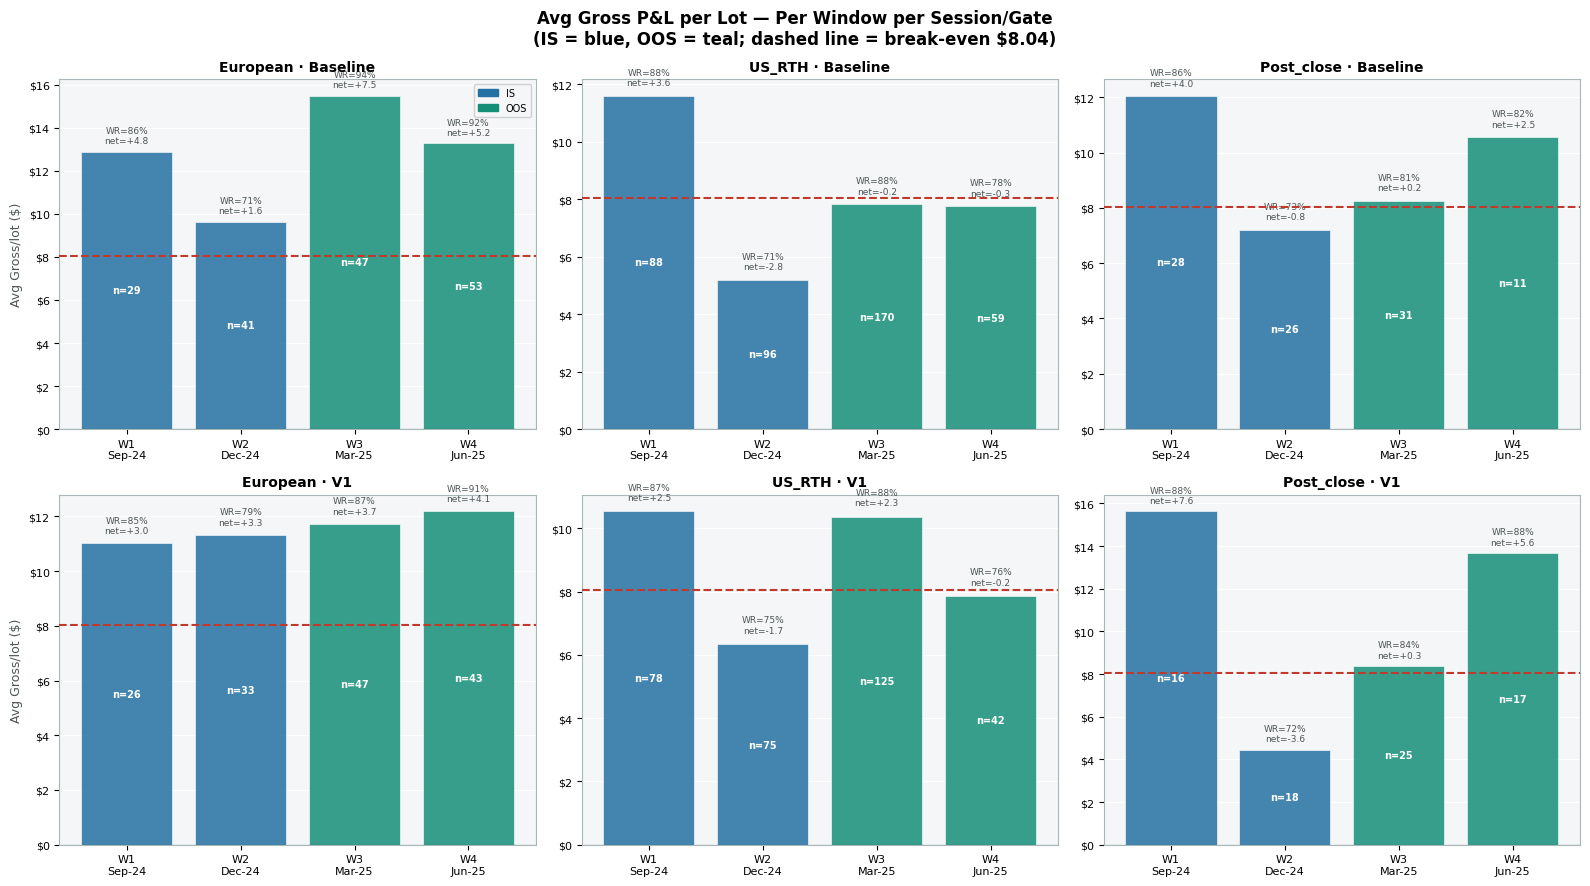

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_idx, sess in enumerate(SESSIONS):
    for row_idx, gate in enumerate(GATES):
        ax  = axes[row_idx][col_idx]
        lbl = f'{sess}_{gate}'
        wks, avgs_g, avgs_n, wrs, ns, colors = [], [], [], [], [], []
        for wk, (wdir, wlabel, period, split) in WINDOWS.items():
            df = load(wdir, lbl)
            s  = stats(df)
            if not s: continue
            wks.append(f'{wk}\n{period}')
            avgs_g.append(s['avg_g'])
            avgs_n.append(s['avg_n'])
            wrs.append(s['wr'])
            ns.append(s['n'])
            colors.append(C_IS if split == 'IS' else C_OOS)

        x = np.arange(len(wks))
        bars = ax.bar(x, avgs_g, color=colors, alpha=0.85, edgecolor='white', lw=0.5, zorder=3)
        ax.axhline(TC,  color=RED,   lw=1.5, ls='--', zorder=4, label=f'BE gross=${TC}')
        ax.axhline(0,   color=DGRAY, lw=0.8, zorder=4)

        for xi, (avg_g, avg_n, wr, n) in enumerate(zip(avgs_g, avgs_n, wrs, ns)):
            net_lbl = f'net={avg_n:+.1f}'
            ax.text(xi, avg_g + 0.3, f'WR={wr:.0f}%\n{net_lbl}',
                    ha='center', va='bottom', fontsize=6.5, color=DGRAY)
            ax.text(xi, avg_g / 2, f'n={n}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

        ax.set_xticks(x); ax.set_xticklabels(wks, fontsize=8)
        ax.set_title(f'{sess} · {gate}', fontsize=10)
        ax.set_ylabel('Avg Gross/lot ($)' if col_idx == 0 else '')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
        ax.grid(True, axis='y', zorder=0)
        if col_idx == 0 and row_idx == 0:
            is_patch  = mpatches.Patch(color=C_IS,  label='IS')
            oos_patch = mpatches.Patch(color=C_OOS, label='OOS')
            ax.legend(handles=[is_patch, oos_patch], fontsize=7, loc='upper right')

fig.suptitle('Avg Gross P&L per Lot — Per Window per Session/Gate\n'
             '(IS = blue, OOS = teal; dashed line = break-even $8.04)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · European Session Deep-Dive
The only statistically significant session. Per-window equity curves and significance.

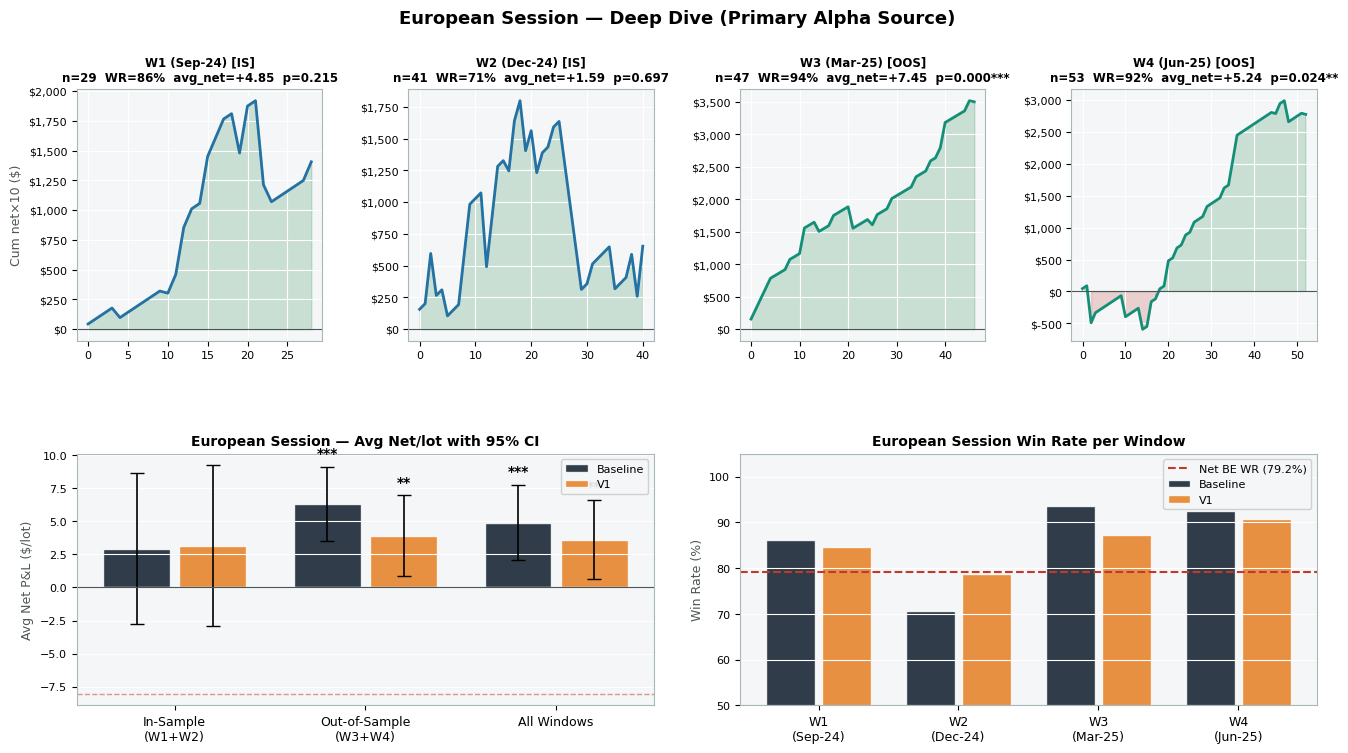

In [7]:
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# Top row: per-window equity curve for European_Baseline
for col, (wk, (wdir, wlabel, period, split)) in enumerate(WINDOWS.items()):
    ax  = fig.add_subplot(gs[0, col])
    df  = load(wdir, 'European_Baseline')
    if df.empty: continue
    net = (df['gross_usd'] - TC) * N_LOTS
    cum = net.cumsum().reset_index(drop=True)
    color = C_IS if split == 'IS' else C_OOS
    ax.fill_between(range(len(cum)), 0, cum, where=cum>=0, alpha=0.2, color=GREEN)
    ax.fill_between(range(len(cum)), 0, cum, where=cum<0,  alpha=0.2, color=RED)
    ax.plot(cum, color=color, lw=2)
    ax.axhline(0, color=DGRAY, lw=0.8)
    s = stats(df)
    ax.set_title(f'{wk} ({period}) [{split}]\nn={s["n"]}  WR={s["wr"]:.0f}%  '
                 f'avg_net={s["avg_n"]:+.2f}  p={s["p"]:.3f}{sig_label(s["p"])}',
                 fontsize=8.5)
    ax.set_ylabel('Cum net×10 ($)' if col==0 else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
    ax.grid(True)

# Bottom row: IS vs OOS CI comparison for European Baseline and V1
ax_ci = fig.add_subplot(gs[1, :2])
splits = ['IS', 'OOS', 'ALL']
split_labels = ['In-Sample\n(W1+W2)', 'Out-of-Sample\n(W3+W4)', 'All Windows']
for g_idx, gate in enumerate(GATES):
    lbl    = f'European_{gate}'
    avgs   = [ss.get((lbl, sp), {}).get('avg_n', np.nan) for sp in splits]
    ci_los = [ss.get((lbl, sp), {}).get('ci_lo', np.nan) for sp in splits]
    ci_his = [ss.get((lbl, sp), {}).get('ci_hi', np.nan) for sp in splits]
    ps     = [ss.get((lbl, sp), {}).get('p', np.nan)    for sp in splits]
    x = np.arange(len(splits)) + g_idx * 0.4 - 0.2
    color = C_BASE if gate == 'Baseline' else C_V1
    ax_ci.bar(x, avgs, 0.35, color=color, alpha=0.85, label=gate, edgecolor='white')
    ax_ci.errorbar(x, avgs, yerr=[np.array(avgs)-np.array(ci_los),
                                   np.array(ci_his)-np.array(avgs)],
                   fmt='none', color='black', capsize=5, lw=1.2)
    for xi, (avg, p) in enumerate(zip(avgs, ps)):
        stars = sig_label(p)
        if stars:
            ax_ci.text(x[xi], avg + (ci_his[xi]-avg) + 0.5, stars,
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_ci.axhline(0, color=DGRAY, lw=0.8)
ax_ci.axhline(-TC, color=RED, lw=1, ls='--', alpha=0.5)
ax_ci.set_xticks(np.arange(len(splits)))
ax_ci.set_xticklabels(split_labels, fontsize=9)
ax_ci.set_title('European Session — Avg Net/lot with 95% CI', fontsize=10)
ax_ci.set_ylabel('Avg Net P&L ($/lot)')
ax_ci.legend(); ax_ci.grid(True, axis='y')

# Bottom right: Win rate waterfall per window
ax_wr = fig.add_subplot(gs[1, 2:])
wk_labels, wr_base, wr_v1 = [], [], []
for wk, (wdir, wlabel, period, split) in WINDOWS.items():
    wk_labels.append(f'{wk}\n({period})')
    s_b = stats(load(wdir, 'European_Baseline'))
    s_v = stats(load(wdir, 'European_V1'))
    wr_base.append(s_b.get('wr', 0))
    wr_v1.append(s_v.get('wr', 0))

x = np.arange(len(wk_labels))
ax_wr.bar(x - 0.2, wr_base, 0.35, color=C_BASE, alpha=0.85, label='Baseline', edgecolor='white')
ax_wr.bar(x + 0.2, wr_v1,   0.35, color=C_V1,  alpha=0.85, label='V1',       edgecolor='white')
ax_wr.axhline(79.2, color=RED, lw=1.5, ls='--', label='Net BE WR (79.2%)')
ax_wr.set_xticks(x); ax_wr.set_xticklabels(wk_labels, fontsize=9)
ax_wr.set_title('European Session Win Rate per Window', fontsize=10)
ax_wr.set_ylabel('Win Rate (%)')
ax_wr.set_ylim(50, 105)
ax_wr.legend(fontsize=8); ax_wr.grid(True, axis='y')

fig.suptitle('European Session — Deep Dive (Primary Alpha Source)', fontsize=13, fontweight='bold')
plt.show()

---
## 6 · Long vs Short Decomposition
US RTH shorts are the structural drag. The drift_4h gate (V1) filters most shorts but doesn't fully resolve the problem.

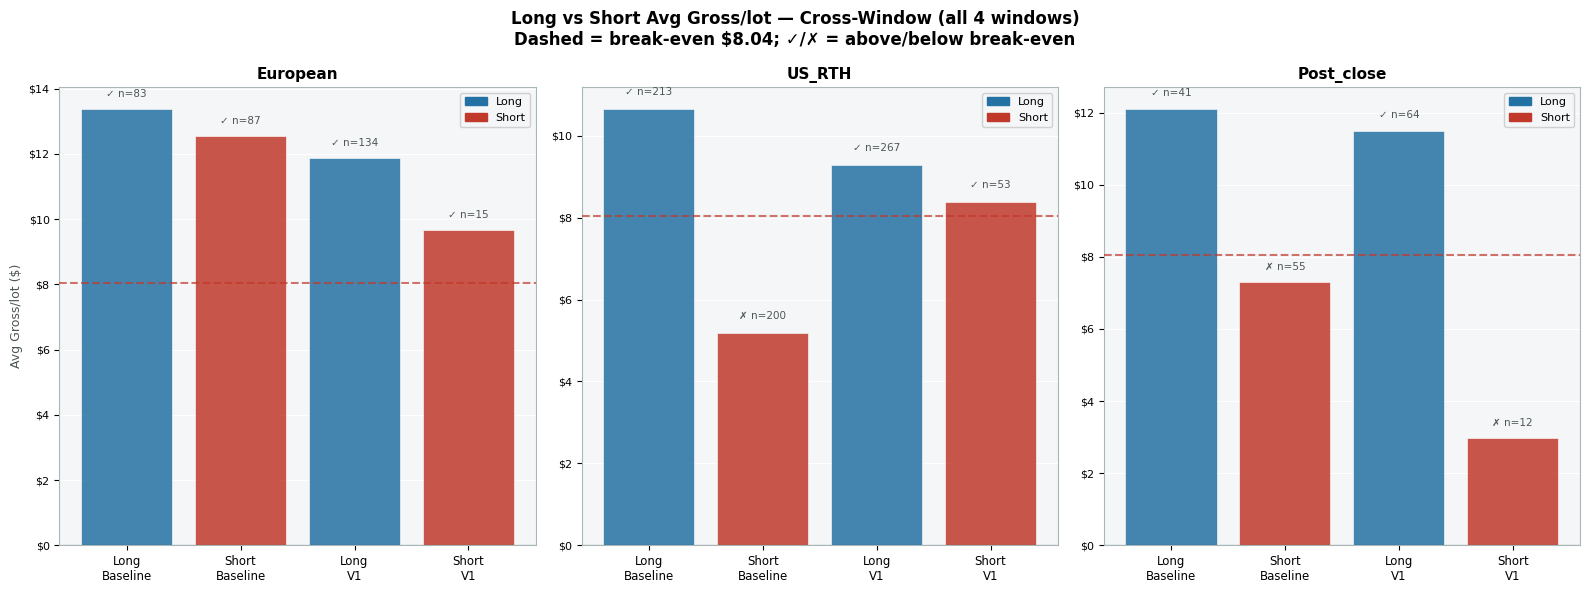

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, sess in zip(axes, SESSIONS):
    categories = ['Long\nBaseline', 'Short\nBaseline', 'Long\nV1', 'Short\nV1']
    avgs_g, ns_plot, colors = [], [], []

    for gate in GATES:
        lbl = f'{sess}_{gate}'
        df  = pool(list(WINDOWS), lbl)
        if df.empty:
            avgs_g.extend([0, 0]); ns_plot.extend([0, 0])
            colors.extend([C_LONG, C_SHORT])
            continue
        for d, color in [(1, C_LONG), (-1, C_SHORT)]:
            sub = df[df['direction'] == d]
            avgs_g.append(sub['gross_usd'].mean() if not sub.empty else 0)
            ns_plot.append(len(sub))
            colors.append(color)

    x = np.arange(len(categories))
    bars = ax.bar(x, avgs_g, color=colors, alpha=0.85, edgecolor='white', lw=0.5, zorder=3)
    ax.axhline(TC, color=RED, lw=1.5, ls='--', alpha=0.7, label=f'BE = ${TC:.2f}', zorder=4)
    ax.axhline(0,  color=DGRAY, lw=0.8, zorder=4)

    for xi, (avg, n) in enumerate(zip(avgs_g, ns_plot)):
        be_str = '✓' if avg >= TC else '✗'
        ax.text(xi, max(avg, 0) + 0.3, f'{be_str} n={n}',
                ha='center', va='bottom', fontsize=7.5, color=DGRAY)

    ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=8.5)
    ax.set_title(f'{sess}', fontsize=11)
    ax.set_ylabel('Avg Gross/lot ($)' if sess == 'European' else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))
    ax.grid(True, axis='y', zorder=0)
    ax.legend(fontsize=8)

    long_patch  = mpatches.Patch(color=C_LONG,  label='Long')
    short_patch = mpatches.Patch(color=C_SHORT, label='Short')
    ax.legend(handles=[long_patch, short_patch], fontsize=8)

fig.suptitle('Long vs Short Avg Gross/lot — Cross-Window (all 4 windows)\n'
             'Dashed = break-even $8.04; ✓/✗ = above/below break-even',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 · Z-Score Segmentation at Fill
Three buckets: low-z (|z|<2), mid-z (2–3), high-z (|z|≥3). Low-z is 74% of trades but below break-even.

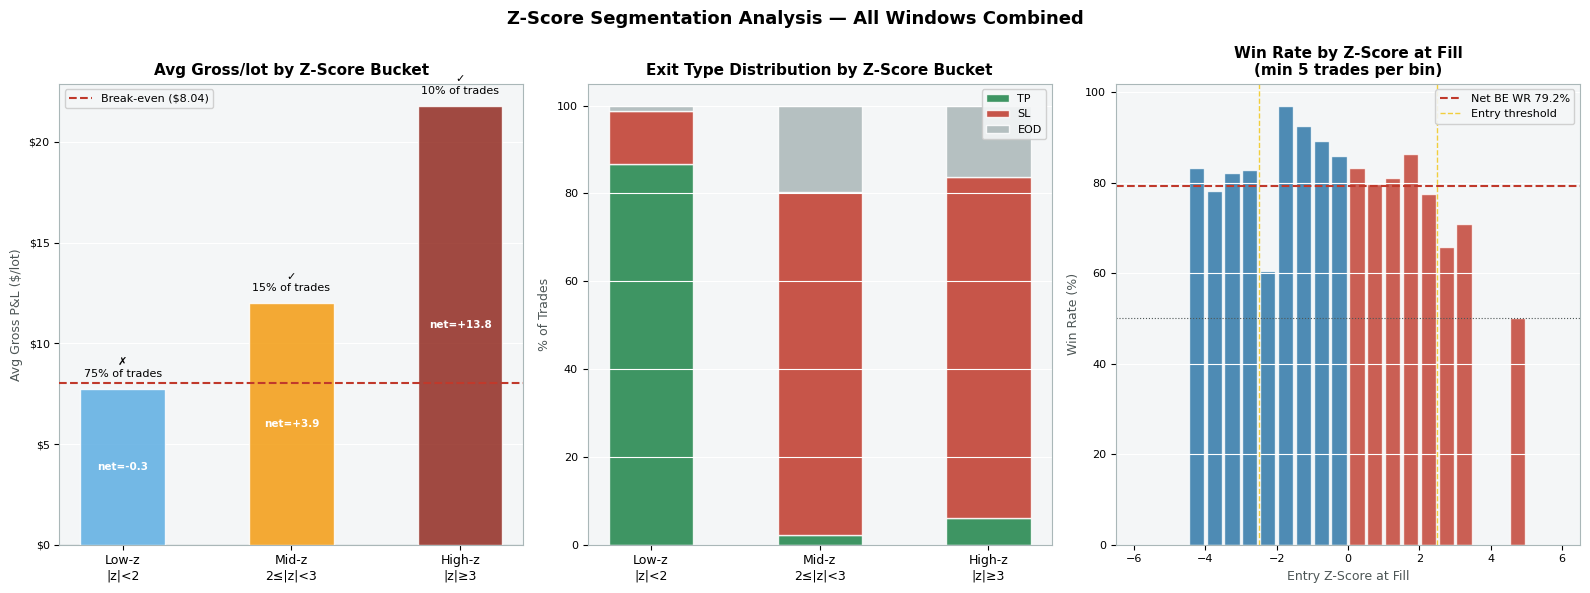

In [9]:
all_parts = []
for wk, (wdir, *_) in WINDOWS.items():
    for lbl in [f'{s}_{g}' for s in SESSIONS for g in GATES]:
        df = load(wdir, lbl)
        if not df.empty:
            df = df.copy(); df['window'] = wk
            all_parts.append(df)
all_df = pd.concat(all_parts, ignore_index=True) if all_parts else pd.DataFrame()

buckets = [
    ('Low-z\n|z|<2',  all_df['entry_z'].abs() < 2.0,   '#5dade2'),
    ('Mid-z\n2≤|z|<3',(all_df['entry_z'].abs()>=2)&(all_df['entry_z'].abs()<3), '#f39c12'),
    ('High-z\n|z|≥3', all_df['entry_z'].abs() >= 3.0,  '#922b21'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Panel A: avg gross comparison
ax = axes[0]
blabels, avgs_g, avgs_n, n_pcts, colors = [], [], [], [], []
for blabel, mask, color in buckets:
    sub = all_df[mask]
    blabels.append(blabel); colors.append(color)
    avgs_g.append(sub['gross_usd'].mean())
    avgs_n.append(sub['gross_usd'].mean() - TC)
    n_pcts.append(len(sub)/len(all_df)*100)

x = np.arange(len(blabels))
bars = ax.bar(x, avgs_g, color=colors, alpha=0.85, edgecolor='white', width=0.5, zorder=3)
ax.axhline(TC, color=RED, lw=1.5, ls='--', label=f'Break-even (${TC:.2f})', zorder=4)
ax.axhline(0,  color=DGRAY, lw=0.8)
for xi, (avg_g, avg_n, pct) in enumerate(zip(avgs_g, avgs_n, n_pcts)):
    be = '✓' if avg_g >= TC else '✗'
    ax.text(xi, avg_g + 0.5, f'{be}\n{pct:.0f}% of trades', ha='center', va='bottom', fontsize=8)
    ax.text(xi, avg_g/2, f'net={avg_n:+.1f}', ha='center', va='center', fontsize=7.5,
            color='white', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(blabels, fontsize=9)
ax.set_title('Avg Gross/lot by Z-Score Bucket')
ax.set_ylabel('Avg Gross P&L ($/lot)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))
ax.legend(fontsize=8); ax.grid(True, axis='y', zorder=0)

# Panel B: exit type breakdown per bucket
ax2 = axes[1]
exit_tp  = [all_df[mask]['exit_type'].eq('TP').mean()*100  for _, mask, _ in buckets]
exit_sl  = [all_df[mask]['exit_type'].eq('SL').mean()*100  for _, mask, _ in buckets]
exit_eod = [all_df[mask]['exit_type'].eq('EOD').mean()*100 for _, mask, _ in buckets]

x2 = np.arange(len(blabels))
ax2.bar(x2, exit_tp,  0.5, label='TP',  color=GREEN,  alpha=0.85, edgecolor='white')
ax2.bar(x2, exit_sl,  0.5, label='SL',  color=RED,    alpha=0.85, edgecolor='white', bottom=exit_tp)
ax2.bar(x2, exit_eod, 0.5, label='EOD', color=MGRAY,  alpha=0.85, edgecolor='white',
        bottom=[t+s for t,s in zip(exit_tp, exit_sl)])
ax2.set_xticks(x2); ax2.set_xticklabels(blabels, fontsize=9)
ax2.set_title('Exit Type Distribution by Z-Score Bucket')
ax2.set_ylabel('% of Trades')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8); ax2.grid(True, axis='y', zorder=0)

# Panel C: win rate vs z-score bin (finer granularity)
ax3 = axes[2]
bins   = np.linspace(-6, 6, 25)
mid    = (bins[:-1] + bins[1:]) / 2
all_df['z_bin'] = pd.cut(all_df['entry_z'], bins=bins, labels=mid)
wr_by_z = all_df.groupby('z_bin', observed=True).apply(
    lambda g: (g['gross_usd']>0).mean()*100 if len(g)>=5 else np.nan
).reset_index()
wr_by_z.columns = ['z_bin', 'wr']
wr_by_z['z_bin'] = wr_by_z['z_bin'].astype(float)
wr_by_z = wr_by_z.dropna()

ax3.bar(wr_by_z['z_bin'], wr_by_z['wr'],
        width=(bins[1]-bins[0])*0.85,
        color=[RED if z>0 else STEEL for z in wr_by_z['z_bin']],
        alpha=0.8, edgecolor='white')
ax3.axhline(79.2, color=RED,   lw=1.5, ls='--', label='Net BE WR 79.2%')
ax3.axhline(50,   color=DGRAY, lw=0.8, ls=':')
ax3.axvline(-2.5, color=GOLD,  lw=1,   ls='--', alpha=0.8, label='Entry threshold')
ax3.axvline( 2.5, color=GOLD,  lw=1,   ls='--', alpha=0.8)
ax3.set_xlabel('Entry Z-Score at Fill')
ax3.set_ylabel('Win Rate (%)')
ax3.set_title('Win Rate by Z-Score at Fill\n(min 5 trades per bin)')
ax3.set_xlim(-6.5, 6.5)
ax3.legend(fontsize=8)
ax3.grid(True, axis='y', zorder=0)

fig.suptitle('Z-Score Segmentation Analysis — All Windows Combined', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8 · HC Add-On Analysis
High-conviction trades (|z_fill|>3, z holds at T+2) double the lot size. W1 is exceptional; W3 has one catastrophic stop-gap.

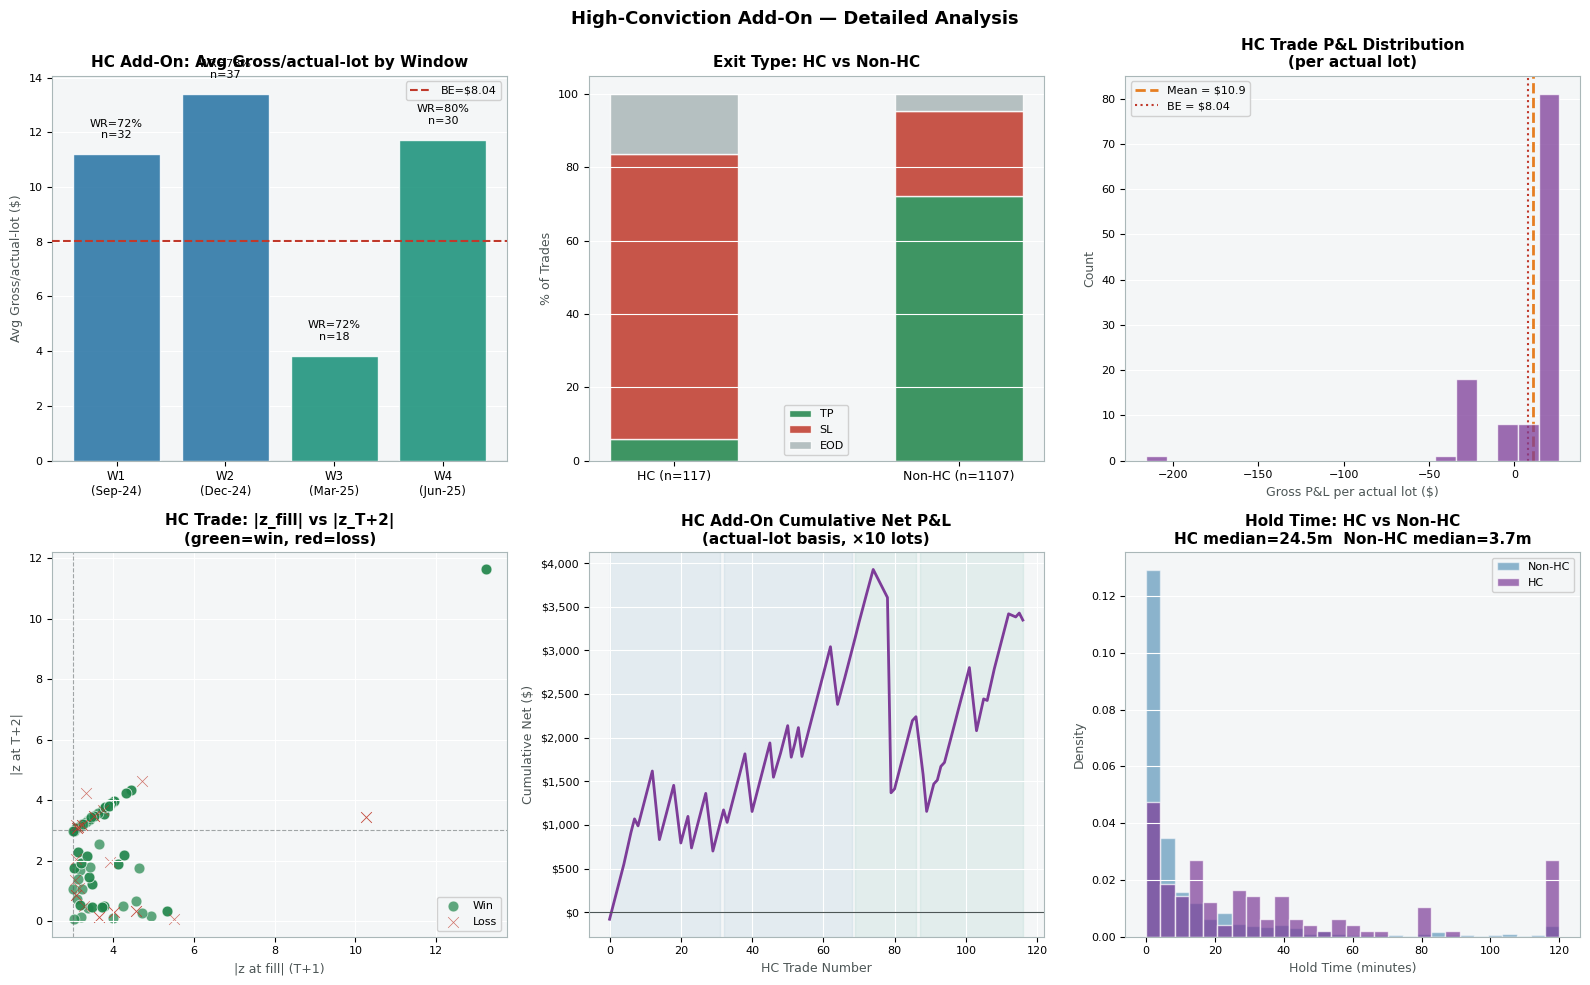

In [10]:
hc_parts, nohc_parts = [], []
for wk, (wdir, *_) in WINDOWS.items():
    for lbl in [f'{s}_{g}' for s in SESSIONS for g in GATES]:
        df = load(wdir, lbl)
        if df.empty or 'hc_addon' not in df.columns: continue
        df = df.copy(); df['window'] = wk
        hc_parts.append(df[df['hc_addon']==True])
        nohc_parts.append(df[df['hc_addon']==False])

hc_all   = pd.concat(hc_parts,   ignore_index=True) if hc_parts   else pd.DataFrame()
nohc_all = pd.concat(nohc_parts, ignore_index=True) if nohc_parts else pd.DataFrame()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Panel (0,0): per-window HC count and WR ───────────────────────────────────
ax = axes[0][0]
wk_labels_hc, hc_wrs, hc_avgs, hc_ns, hc_colors = [], [], [], [], []
for wk, (wdir, wlabel, period, split) in WINDOWS.items():
    wdfs = []
    for lbl in [f'{s}_{g}' for s in SESSIONS for g in GATES]:
        df = load(wdir, lbl)
        if not df.empty and 'hc_addon' in df.columns:
            wdfs.append(df[df['hc_addon']==True])
    if not wdfs: continue
    wdf = pd.concat(wdfs, ignore_index=True)
    if wdf.empty: continue
    wk_labels_hc.append(f'{wk}\n({period})')
    hc_wrs.append((wdf['gross_usd']>0).mean()*100)
    hc_avgs.append(wdf['gross_usd'].mean() / 2)  # per actual lot
    hc_ns.append(len(wdf))
    hc_colors.append(C_IS if split=='IS' else C_OOS)

x = np.arange(len(wk_labels_hc))
ax.bar(x, hc_avgs, color=hc_colors, alpha=0.85, edgecolor='white', zorder=3)
ax.axhline(TC,  color=RED,   lw=1.5, ls='--', label=f'BE=${TC}', zorder=4)
ax.axhline(0,   color=DGRAY, lw=0.8)
for xi, (wr, n, avg) in enumerate(zip(hc_wrs, hc_ns, hc_avgs)):
    ax.text(xi, max(avg,0)+0.5, f'WR={wr:.0f}%\nn={n}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(wk_labels_hc, fontsize=8.5)
ax.set_title('HC Add-On: Avg Gross/actual-lot by Window')
ax.set_ylabel('Avg Gross/actual-lot ($)')
ax.legend(fontsize=8); ax.grid(True, axis='y', zorder=0)

# ── Panel (0,1): exit type HC vs non-HC ──────────────────────────────────────
ax2 = axes[0][1]
groups = [('HC (n='+str(len(hc_all))+')', hc_all), ('Non-HC (n='+str(len(nohc_all))+')', nohc_all)]
x_g   = np.arange(len(groups))
for et, color, label in [('TP', GREEN, 'TP'), ('SL', RED, 'SL'), ('EOD', MGRAY, 'EOD')]:
    vals = []
    bottoms = []
    for gname, gdf in groups:
        vals.append(gdf['exit_type'].eq(et).mean()*100 if not gdf.empty else 0)
    if et == 'TP':
        ax2.bar(x_g, vals, 0.45, label=label, color=color, alpha=0.85, edgecolor='white')
        prev = np.array(vals)
    elif et == 'SL':
        ax2.bar(x_g, vals, 0.45, label=label, color=color, alpha=0.85, edgecolor='white', bottom=prev)
        prev = prev + np.array(vals)
    else:
        ax2.bar(x_g, vals, 0.45, label=label, color=color, alpha=0.85, edgecolor='white', bottom=prev)
ax2.set_xticks(x_g); ax2.set_xticklabels([g[0] for g in groups], fontsize=9)
ax2.set_title('Exit Type: HC vs Non-HC')
ax2.set_ylabel('% of Trades')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8); ax2.grid(True, axis='y')

# ── Panel (0,2): HC gross distribution ───────────────────────────────────────
ax3 = axes[0][2]
if not hc_all.empty:
    gross_actual = hc_all['gross_usd'] / 2
    ax3.hist(gross_actual, bins=20, color=PURPLE, alpha=0.75, edgecolor='white', zorder=3)
    ax3.axvline(gross_actual.mean(), color=ORANGE, lw=2, ls='--',
                label=f'Mean = ${gross_actual.mean():.1f}')
    ax3.axvline(TC, color=RED, lw=1.5, ls=':', label=f'BE = ${TC}')
    ax3.set_title('HC Trade P&L Distribution\n(per actual lot)')
    ax3.set_xlabel('Gross P&L per actual lot ($)')
    ax3.set_ylabel('Count')
    ax3.legend(fontsize=8); ax3.grid(True, axis='y')

# ── Panel (1,0): scatter z-fill vs z-T+2 (HC triggered vs not) ──────────────
ax4 = axes[1][0]
hc_pool = []
for wk, (wdir, *_) in WINDOWS.items():
    for lbl in [f'{s}_{g}' for s in SESSIONS for g in GATES]:
        df = load(wdir, lbl)
        if not df.empty and 'hc_addon' in df.columns and 'entry_z2' in df.columns:
            sub = df[df['hc_addon']==True].copy()
            sub['window'] = wk
            hc_pool.append(sub)
if hc_pool:
    hc_scatter = pd.concat(hc_pool, ignore_index=True)
    win_mask = hc_scatter['gross_usd'] > 0
    ax4.scatter(hc_scatter.loc[win_mask, 'entry_z'].abs(),
                hc_scatter.loc[win_mask, 'entry_z2'].abs(),
                c=GREEN, alpha=0.7, s=60, label='Win', edgecolors='white', lw=0.5)
    ax4.scatter(hc_scatter.loc[~win_mask, 'entry_z'].abs(),
                hc_scatter.loc[~win_mask, 'entry_z2'].abs(),
                c=RED, alpha=0.7, s=60, label='Loss', edgecolors='white', lw=0.5, marker='x')
    ax4.axhline(3.0, color=DGRAY, lw=0.8, ls='--', alpha=0.5)
    ax4.axvline(3.0, color=DGRAY, lw=0.8, ls='--', alpha=0.5)
    ax4.set_xlabel('|z at fill| (T+1)')
    ax4.set_ylabel('|z at T+2|')
    ax4.set_title('HC Trade: |z_fill| vs |z_T+2|\n(green=win, red=loss)')
    ax4.legend(fontsize=8); ax4.grid(True)

# ── Panel (1,1): HC cumulative P&L over time ─────────────────────────────────
ax5 = axes[1][1]
if not hc_all.empty:
    hc_sorted = hc_all.sort_values('entry_time').reset_index(drop=True)
    hc_sorted['net_actual'] = hc_sorted['gross_usd']/2 - TC
    hc_sorted['cum'] = hc_sorted['net_actual'].cumsum() * N_LOTS
    for wk, (wdir, wlabel, period, split) in WINDOWS.items():
        wmask = hc_sorted['window'] == wk
        if wmask.any():
            color = C_IS if split=='IS' else C_OOS
            idx = hc_sorted[wmask].index
            ax5.axvspan(idx[0], idx[-1], color=color, alpha=0.08)
    ax5.plot(hc_sorted['cum'], color=PURPLE, lw=2)
    ax5.axhline(0, color=DGRAY, lw=0.8)
    ax5.set_title('HC Add-On Cumulative Net P&L\n(actual-lot basis, ×10 lots)')
    ax5.set_xlabel('HC Trade Number')
    ax5.set_ylabel('Cumulative Net ($)')
    ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
    ax5.grid(True)

# ── Panel (1,2): HC hold time distribution ──────────────────────────────────
ax6 = axes[1][2]
if not hc_all.empty and not nohc_all.empty:
    hc_hold   = hc_all['hold_min'].clip(0, 120)
    nohc_hold = nohc_all['hold_min'].clip(0, 120)
    bins_h = np.linspace(0, 120, 30)
    ax6.hist(nohc_hold, bins=bins_h, alpha=0.5, color=STEEL, label='Non-HC', density=True, edgecolor='white')
    ax6.hist(hc_hold,   bins=bins_h, alpha=0.7, color=PURPLE, label='HC',     density=True, edgecolor='white')
    ax6.set_xlabel('Hold Time (minutes)')
    ax6.set_ylabel('Density')
    ax6.set_title(f'Hold Time: HC vs Non-HC\n'
                  f'HC median={hc_hold.median():.1f}m  Non-HC median={nohc_hold.median():.1f}m')
    ax6.legend(fontsize=8); ax6.grid(True, axis='y')

fig.suptitle('High-Conviction Add-On — Detailed Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9 · Statistical Significance — Forest Plot
95% confidence intervals on avg net P&L/lot. Points to the right of zero are profitable; CI entirely right of zero = significant.

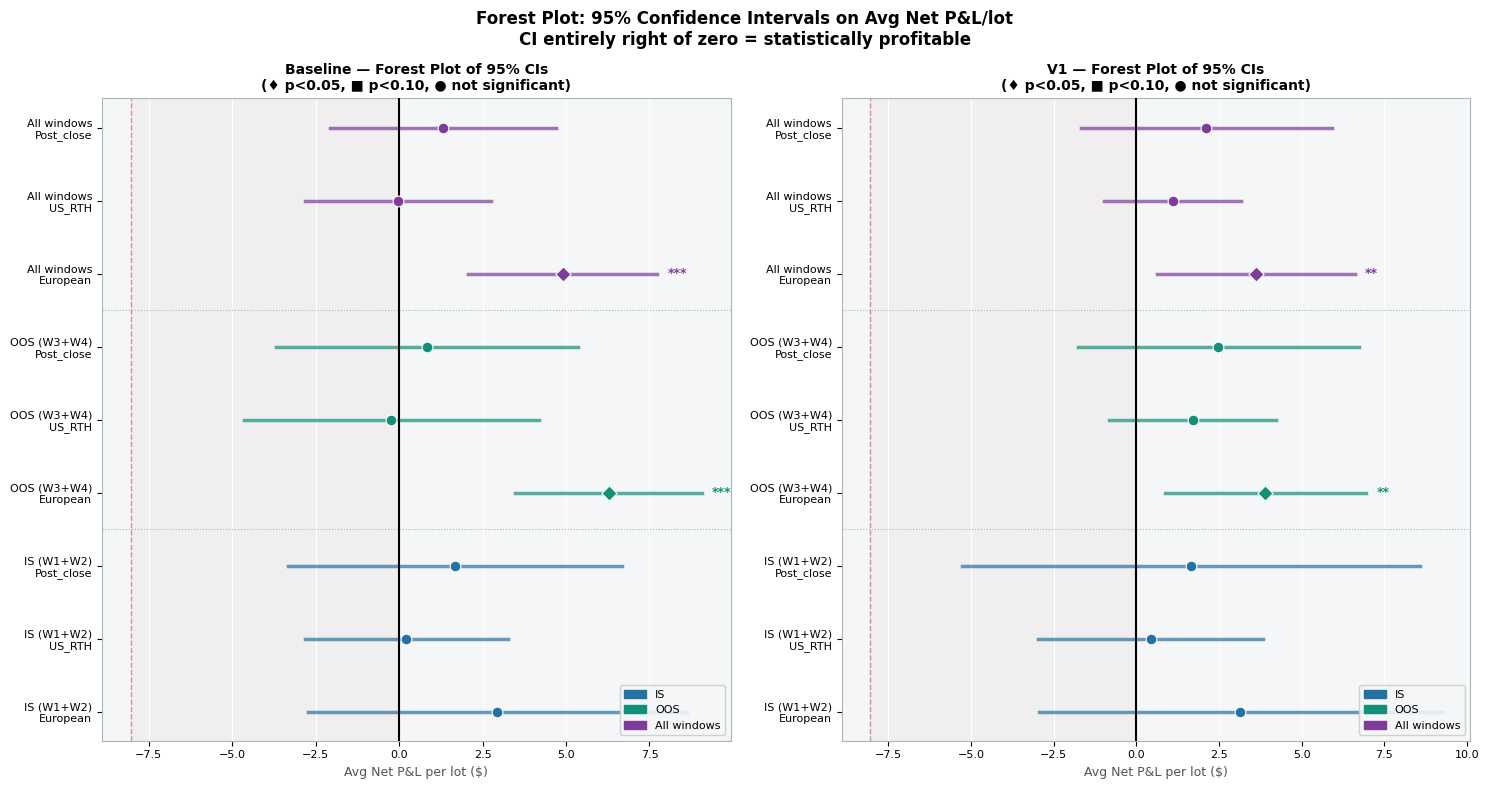

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=False)

for ax, gate in zip(axes, GATES):
    labels_g  = [f'{s}_{gate}' for s in SESSIONS]
    row_labels, means, ci_los, ci_his, ps, colors_fp = [], [], [], [], [], []

    for split in ['IS', 'OOS', 'ALL']:
        split_label = {'IS': 'IS (W1+W2)', 'OOS': 'OOS (W3+W4)', 'ALL': 'All windows'}[split]
        for lbl in labels_g:
            s = ss.get((lbl, split), {})
            if not s: continue
            row_labels.append(f'{split_label}\n{lbl.replace("_"+gate,"")}')  
            means.append(s['avg_n'])
            ci_los.append(s['ci_lo'])
            ci_his.append(s['ci_hi'])
            ps.append(s['p'])
            if split == 'IS':    colors_fp.append(C_IS)
            elif split == 'OOS': colors_fp.append(C_OOS)
            else:                colors_fp.append(PURPLE)

    y = np.arange(len(row_labels))
    for yi, (m, lo, hi, p, c) in enumerate(zip(means, ci_los, ci_his, ps, colors_fp)):
        ax.plot([lo, hi], [yi, yi], color=c, lw=2.5, alpha=0.7)
        marker = 'D' if p < 0.05 else ('s' if p < 0.10 else 'o')
        ax.scatter(m, yi, color=c, s=60, zorder=5, marker=marker, edgecolors='white', lw=0.8)
        stars = sig_label(p)
        if stars:
            ax.text(hi + 0.3, yi, stars, va='center', fontsize=9, color=c, fontweight='bold')

    ax.axvline(0,   color='black', lw=1.5, zorder=4)
    ax.axvline(-TC, color=RED, lw=1, ls='--', alpha=0.5, label='−TC ($−8.04)')
    ax.axvspan(-TC, 0, color=RED, alpha=0.04)

    # Section dividers (IS / OOS / ALL)
    n_sess = len(SESSIONS)
    for sep in [n_sess - 0.5, 2*n_sess - 0.5]:
        ax.axhline(sep, color=MGRAY, lw=0.8, ls=':')

    ax.set_yticks(y); ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel('Avg Net P&L per lot ($)')
    ax.set_title(f'{gate} — Forest Plot of 95% CIs\n'
                 f'(♦ p<0.05, ■ p<0.10, ● not significant)', fontsize=10)

    is_p  = mpatches.Patch(color=C_IS,   label='IS')
    oos_p = mpatches.Patch(color=C_OOS,  label='OOS')
    all_p = mpatches.Patch(color=PURPLE, label='All windows')
    ax.legend(handles=[is_p, oos_p, all_p], fontsize=8, loc='lower right')
    ax.grid(True, axis='x', zorder=0)

fig.suptitle('Forest Plot: 95% Confidence Intervals on Avg Net P&L/lot\n'
             'CI entirely right of zero = statistically profitable', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10 · Risk Metrics — Drawdown & MDD Comparison

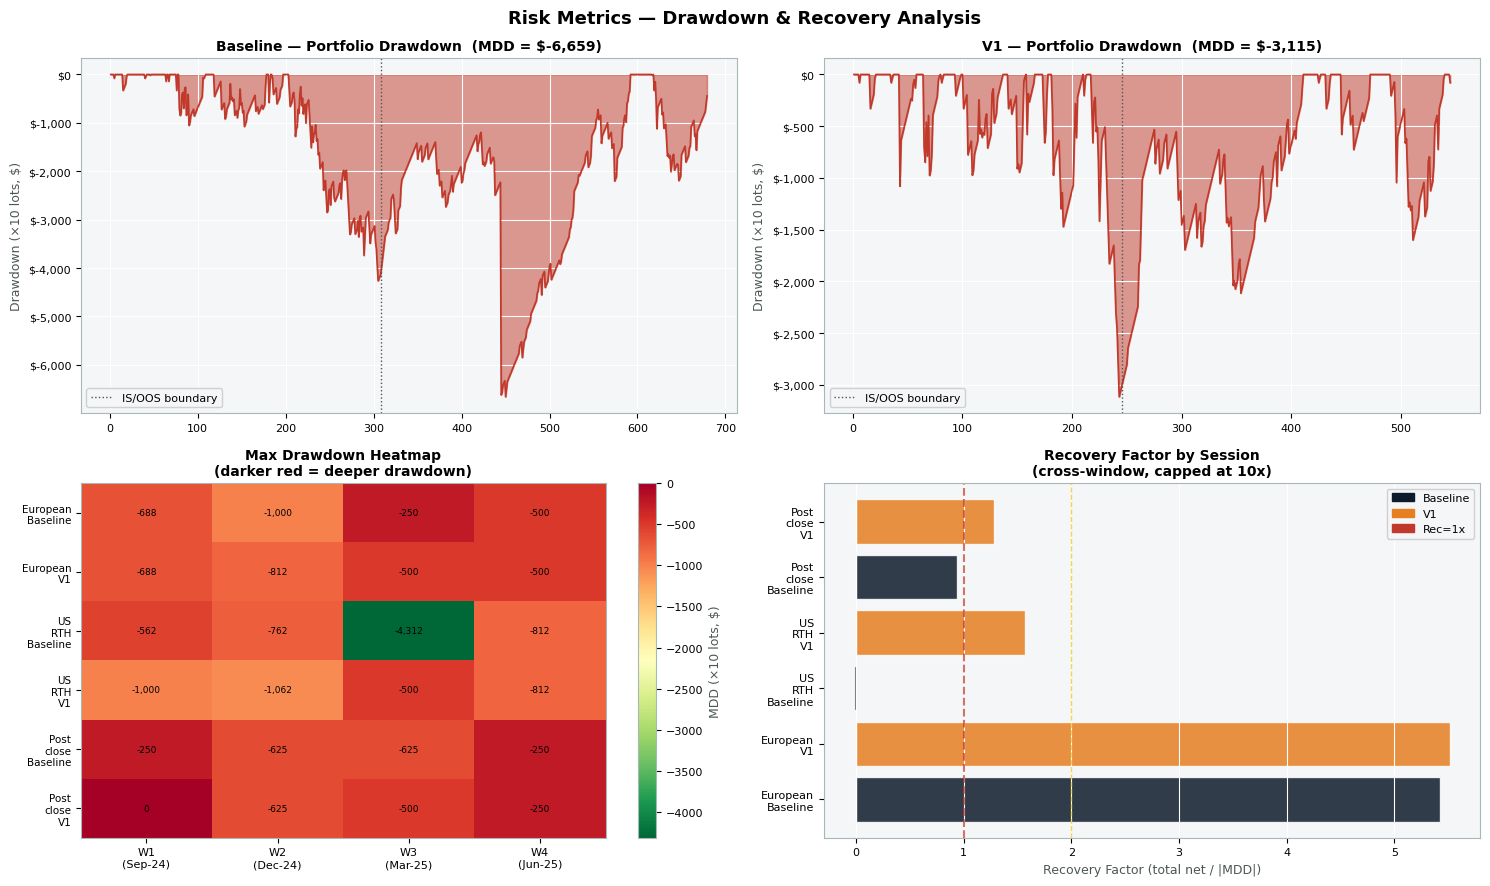

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ── Panel (0,0)+(0,1): per-gate drawdown curve ──────────────────────────────
for ax, gate in zip(axes[0], GATES):
    labels_g = [f'{s}_{gate}' for s in SESSIONS]
    port_parts = []
    for wk, (wdir, wlabel, period, split) in WINDOWS.items():
        for lbl in labels_g:
            df = load(wdir, lbl)
            if not df.empty:
                df = df.copy(); df['window']=wk; df['split']=split
                port_parts.append(df)
    if not port_parts: continue
    port = pd.concat(port_parts, ignore_index=True).sort_values('entry_time').reset_index(drop=True)
    port['net'] = (port['gross_usd'] - TC) * N_LOTS
    port['cum'] = port['net'].cumsum()
    port['pk']  = port['cum'].cummax()
    port['dd']  = port['cum'] - port['pk']
    port['tn']  = np.arange(1, len(port)+1)

    ax.fill_between(port['tn'], port['dd'], 0, alpha=0.5,
                    color=RED if port['dd'].min() < -2000 else ORANGE)
    ax.plot(port['tn'], port['dd'], color=RED, lw=1.2)

    is_end = port[port['split']=='IS']['tn'].max()
    ax.axvline(is_end, color=DGRAY, lw=1, ls=':', label='IS/OOS boundary')
    mdd = port['dd'].min()
    ax.set_title(f'{gate} — Portfolio Drawdown  (MDD = ${mdd*1:,.0f})', fontsize=10)
    ax.set_ylabel('Drawdown (×10 lots, $)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
    ax.legend(fontsize=8); ax.grid(True)

# ── Panel (1,0): MDD heatmap by session × window ──────────────────────────────
ax3 = axes[1][0]
mdd_data = np.zeros((len(ALL_LABELS), len(WINDOWS)))
for j, (wk, (wdir, *_)) in enumerate(WINDOWS.items()):
    for i, lbl in enumerate(ALL_LABELS):
        df = load(wdir, lbl)
        if df.empty:
            mdd_data[i, j] = 0
        else:
            g = df['gross_usd']
            cum = g.cumsum()
            mdd_data[i, j] = (cum - cum.cummax()).min() * N_LOTS

im = ax3.imshow(mdd_data, aspect='auto', cmap='RdYlGn_r',
                vmin=mdd_data.min(), vmax=0)
ax3.set_xticks(range(len(WINDOWS)))
ax3.set_xticklabels([f'{wk}\n({WINDOWS[wk][2]})' for wk in WINDOWS], fontsize=8)
ax3.set_yticks(range(len(ALL_LABELS)))
ax3.set_yticklabels([lbl.replace('_', '\n') for lbl in ALL_LABELS], fontsize=7.5)
plt.colorbar(im, ax=ax3, label='MDD (×10 lots, $)')
ax3.set_title('Max Drawdown Heatmap\n(darker red = deeper drawdown)', fontsize=10)
for i in range(len(ALL_LABELS)):
    for j in range(len(WINDOWS)):
        ax3.text(j, i, f'{mdd_data[i,j]:,.0f}', ha='center', va='center',
                 fontsize=6.5, color='black')

# ── Panel (1,1): Recovery factor by session ───────────────────────────────────
ax4 = axes[1][1]
rec_labels, rec_vals, rec_colors = [], [], []
for lbl in ALL_LABELS:
    df = pool(list(WINDOWS), lbl)
    if df.empty: continue
    g   = (df['gross_usd'] - TC) * N_LOTS
    cum = g.cumsum()
    mdd = (cum - cum.cummax()).min()
    rec = cum.iloc[-1] / abs(mdd) if mdd < 0 else 10
    rec_labels.append(lbl.replace('_', '\n'))
    rec_vals.append(min(rec, 10))
    gate = lbl.split('_')[-1]
    rec_colors.append(C_BASE if gate=='Baseline' else C_V1)

y4 = np.arange(len(rec_labels))
bars4 = ax4.barh(y4, rec_vals, color=rec_colors, alpha=0.85, edgecolor='white')
ax4.axvline(1.0, color=RED, lw=1.5, ls='--', label='Recovery = 1.0x (breakeven)', alpha=0.7)
ax4.axvline(2.0, color=GOLD, lw=1, ls='--', label='Recovery = 2.0x', alpha=0.7)
ax4.set_yticks(y4); ax4.set_yticklabels(rec_labels, fontsize=8)
ax4.set_xlabel('Recovery Factor (total net / |MDD|)')
ax4.set_title('Recovery Factor by Session\n(cross-window, capped at 10x)', fontsize=10)
ax4.legend(fontsize=8)
base_patch = mpatches.Patch(color=C_BASE, label='Baseline')
v1_patch   = mpatches.Patch(color=C_V1,  label='V1')
ax4.legend(handles=[base_patch, v1_patch, 
           mpatches.Patch(color=RED, label='Rec=1x')], fontsize=8)
ax4.grid(True, axis='x')

fig.suptitle('Risk Metrics — Drawdown & Recovery Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11 · Trade Characteristics — Hold Time, MAE/MFE, Exit Types

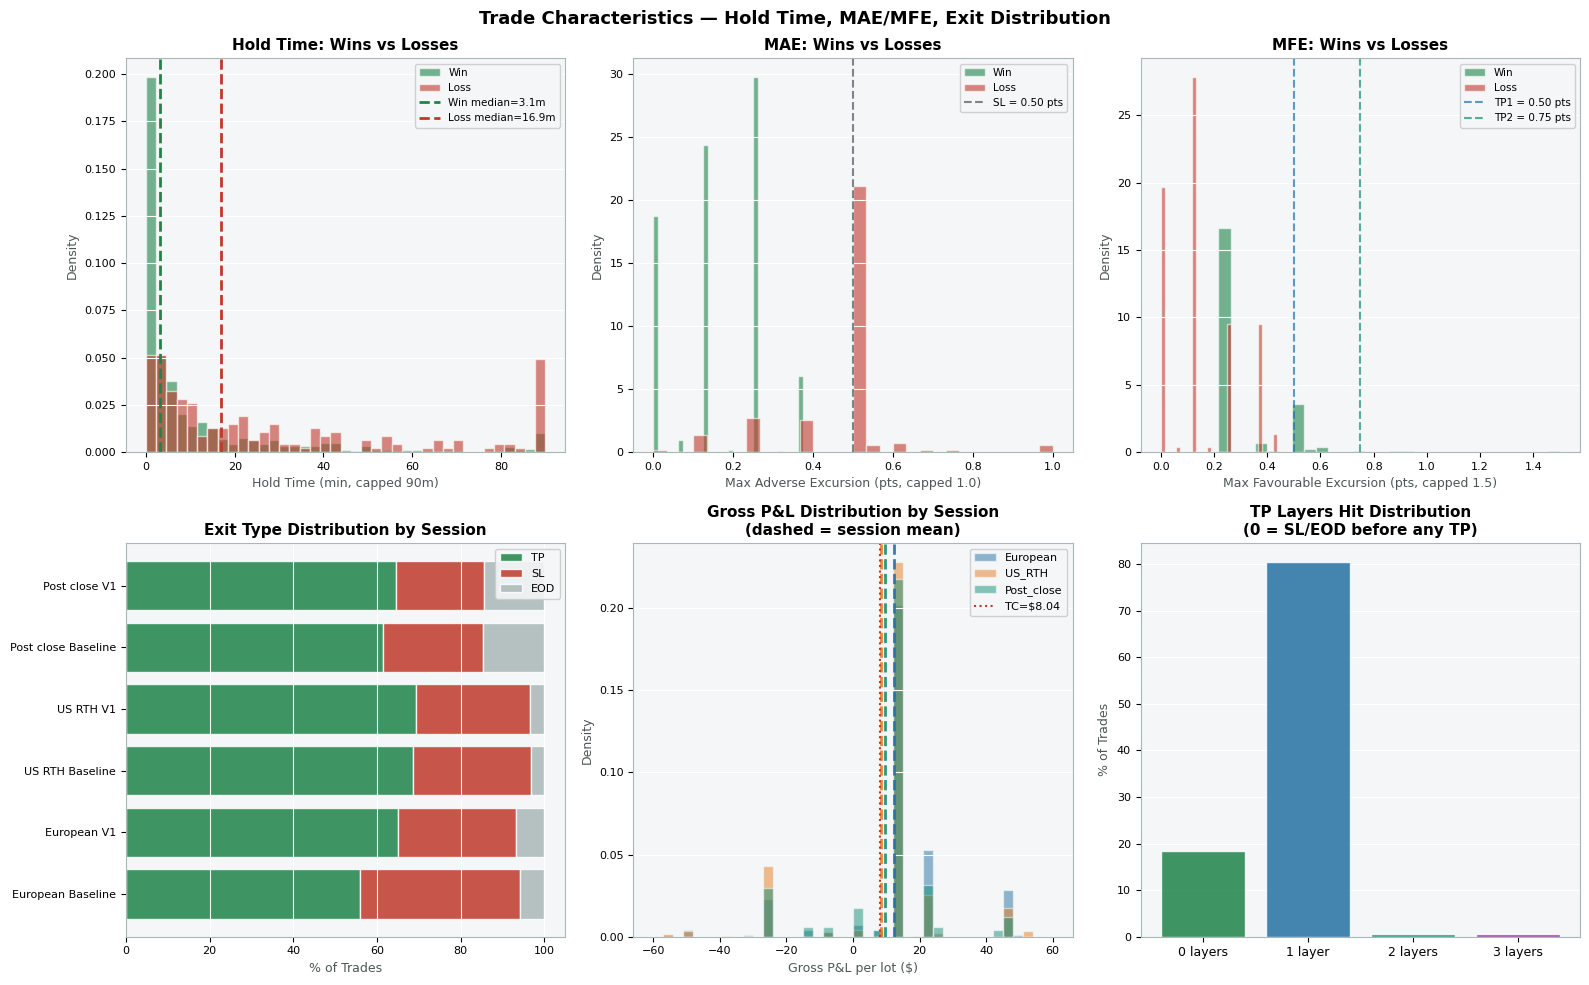

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

combined_all = all_df.copy()  # all trades from all windows and sessions
win_mask_all = combined_all['gross_usd'] > 0

# ── (0,0): Hold time distribution ─────────────────────────────────────────────
ax = axes[0][0]
bins_h = np.linspace(0, 90, 40)
ax.hist(combined_all.loc[ win_mask_all, 'hold_min'].clip(0, 90), bins=bins_h,
        alpha=0.6, color=GREEN, label='Win', density=True, edgecolor='white')
ax.hist(combined_all.loc[~win_mask_all, 'hold_min'].clip(0, 90), bins=bins_h,
        alpha=0.6, color=RED,   label='Loss', density=True, edgecolor='white')
ax.axvline(combined_all.loc[ win_mask_all, 'hold_min'].median(), color=GREEN, lw=2,
           ls='--', label=f'Win median={combined_all.loc[win_mask_all,"hold_min"].median():.1f}m')
ax.axvline(combined_all.loc[~win_mask_all,'hold_min'].median(), color=RED, lw=2,
           ls='--', label=f'Loss median={combined_all.loc[~win_mask_all,"hold_min"].median():.1f}m')
ax.set_xlabel('Hold Time (min, capped 90m)')
ax.set_ylabel('Density')
ax.set_title('Hold Time: Wins vs Losses')
ax.legend(fontsize=7.5); ax.grid(True, axis='y')

# ── (0,1): MAE distribution ───────────────────────────────────────────────────
ax2 = axes[0][1]
ax2.hist(combined_all.loc[ win_mask_all, 'mae_pts'].clip(0, 1), bins=30,
         alpha=0.6, color=GREEN, label='Win', density=True, edgecolor='white')
ax2.hist(combined_all.loc[~win_mask_all,'mae_pts'].clip(0, 1), bins=30,
         alpha=0.6, color=RED,   label='Loss', density=True, edgecolor='white')
ax2.axvline(0.50, color=DGRAY, lw=1.5, ls='--', alpha=0.7, label='SL = 0.50 pts')
ax2.set_xlabel('Max Adverse Excursion (pts, capped 1.0)')
ax2.set_ylabel('Density')
ax2.set_title('MAE: Wins vs Losses')
ax2.legend(fontsize=7.5); ax2.grid(True, axis='y')

# ── (0,2): MFE distribution ───────────────────────────────────────────────────
ax3 = axes[0][2]
ax3.hist(combined_all.loc[ win_mask_all, 'mfe_pts'].clip(0, 1.5), bins=30,
         alpha=0.6, color=GREEN, label='Win', density=True, edgecolor='white')
ax3.hist(combined_all.loc[~win_mask_all,'mfe_pts'].clip(0, 1.5), bins=30,
         alpha=0.6, color=RED,   label='Loss', density=True, edgecolor='white')
ax3.axvline(0.50, color=STEEL, lw=1.5, ls='--', alpha=0.7, label='TP1 = 0.50 pts')
ax3.axvline(0.75, color=TEAL,  lw=1.5, ls='--', alpha=0.7, label='TP2 = 0.75 pts')
ax3.set_xlabel('Max Favourable Excursion (pts, capped 1.5)')
ax3.set_ylabel('Density')
ax3.set_title('MFE: Wins vs Losses')
ax3.legend(fontsize=7.5); ax3.grid(True, axis='y')

# ── (1,0): Exit type by session ───────────────────────────────────────────────
ax4 = axes[1][0]
sess_et_labels = []
tp_rates, sl_rates, eod_rates = [], [], []
for lbl in ALL_LABELS:
    df = pool(list(WINDOWS), lbl)
    if df.empty: continue
    sess_et_labels.append(lbl.replace('_',' '))
    tp_rates.append((df['exit_type']=='TP').mean()*100)
    sl_rates.append((df['exit_type']=='SL').mean()*100)
    eod_rates.append((df['exit_type']=='EOD').mean()*100)

y4 = np.arange(len(sess_et_labels))
ax4.barh(y4, tp_rates,  color=GREEN, alpha=0.85, label='TP',  edgecolor='white')
ax4.barh(y4, sl_rates,  color=RED,   alpha=0.85, label='SL',  edgecolor='white', left=tp_rates)
ax4.barh(y4, eod_rates, color=MGRAY, alpha=0.85, label='EOD', edgecolor='white',
         left=[t+s for t,s in zip(tp_rates, sl_rates)])
ax4.set_yticks(y4); ax4.set_yticklabels(sess_et_labels, fontsize=8)
ax4.set_xlabel('% of Trades')
ax4.set_title('Exit Type Distribution by Session')
ax4.legend(fontsize=8); ax4.grid(True, axis='x')

# ── (1,1): Gross P&L distribution by session type ────────────────────────────
ax5 = axes[1][1]
sess_data  = {s: [] for s in SESSIONS}
for wk, (wdir, *_) in WINDOWS.items():
    for sess in SESSIONS:
        for gate in GATES:
            df = load(wdir, f'{sess}_{gate}')
            if not df.empty:
                sess_data[sess].extend(df['gross_usd'].tolist())

colors_sess = {'European': STEEL, 'US_RTH': ORANGE, 'Post_close': TEAL}
for sess, color in colors_sess.items():
    data = np.array(sess_data[sess])
    ax5.hist(data, bins=40, alpha=0.5, color=color, label=sess,
             density=True, edgecolor='white', range=(-60, 60))
    ax5.axvline(np.mean(data), color=color, lw=2, ls='--', alpha=0.9)
ax5.axvline(TC, color=RED, lw=1.5, ls=':', label=f'TC=${TC}')
ax5.set_xlabel('Gross P&L per lot ($)')
ax5.set_ylabel('Density')
ax5.set_title('Gross P&L Distribution by Session\n(dashed = session mean)')
ax5.legend(fontsize=8); ax5.grid(True, axis='y')

# ── (1,2): Layers hit distribution ───────────────────────────────────────────
ax6 = axes[1][2]
if 'layers_hit' in combined_all.columns:
    lh = combined_all['layers_hit'].value_counts().sort_index()
    ax6.bar(lh.index, lh.values / lh.sum() * 100,
            color=[GREEN, STEEL, TEAL, PURPLE][:len(lh)],
            alpha=0.85, edgecolor='white', zorder=3)
    ax6.set_xticks(lh.index)
    ax6.set_xticklabels([f'{i} layer{"s" if i!=1 else ""}' for i in lh.index], fontsize=9)
    ax6.set_ylabel('% of Trades')
    ax6.set_title('TP Layers Hit Distribution\n(0 = SL/EOD before any TP)')
    ax6.grid(True, axis='y', zorder=0)

fig.suptitle('Trade Characteristics — Hold Time, MAE/MFE, Exit Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12 · Summary Scorecard

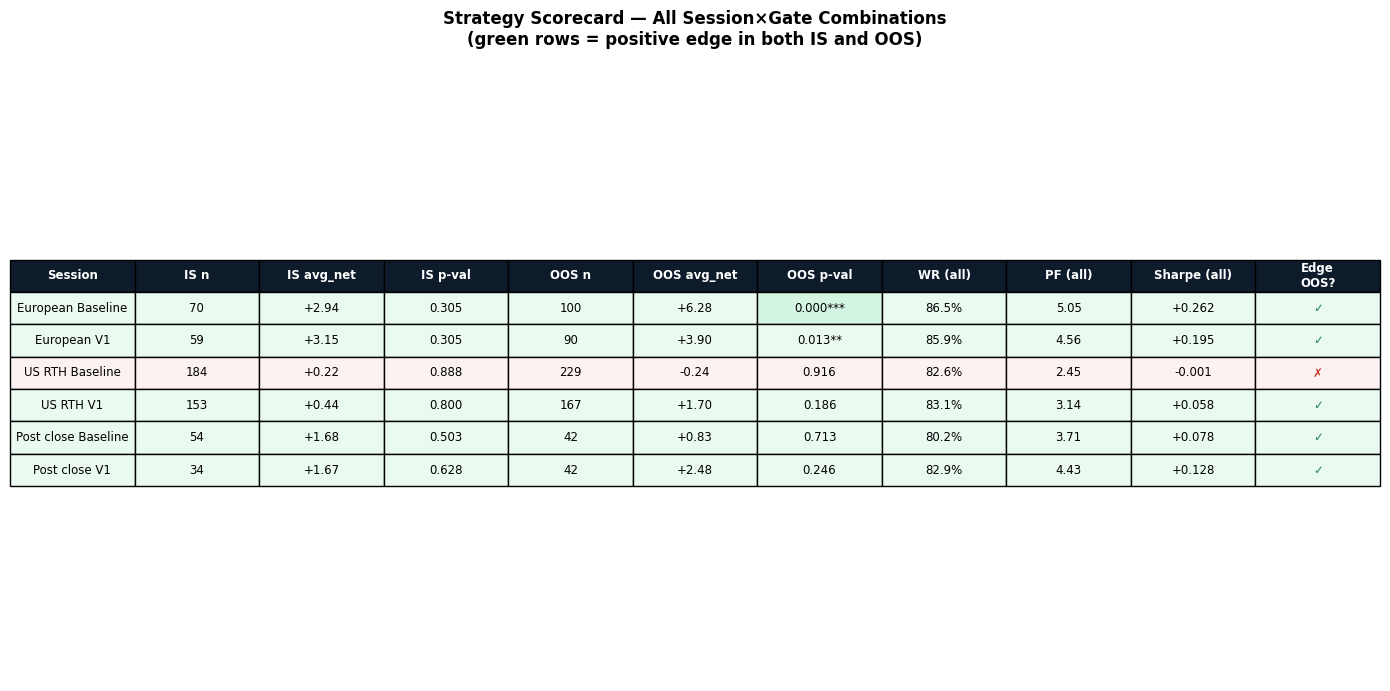

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

# Build scorecard data
rows = []
for lbl in ALL_LABELS:
    s_is  = ss.get((lbl, 'IS'),  {})
    s_oos = ss.get((lbl, 'OOS'), {})
    s_all = ss.get((lbl, 'ALL'), {})
    if not s_all: continue

    def fmt_pval(s):
        if not s: return '—'
        return f"{s['p']:.3f}{sig_label(s['p'])}"

    rows.append([
        lbl.replace('_', ' '),
        f"{s_is.get('n','—')}",
        f"{s_is.get('avg_n',0):+.2f}" if s_is else '—',
        fmt_pval(s_is),
        f"{s_oos.get('n','—')}",
        f"{s_oos.get('avg_n',0):+.2f}" if s_oos else '—',
        fmt_pval(s_oos),
        f"{s_all.get('wr',0):.1f}%",
        f"{s_all.get('pf',0):.2f}",
        f"{s_all.get('sharpe',0):+.3f}",
        '✓' if (s_oos.get('avg_n',0)>0 and s_is.get('avg_n',0)>0) else '✗'
    ])

col_labels = ['Session', 'IS n', 'IS avg_net', 'IS p-val',
              'OOS n', 'OOS avg_net', 'OOS p-val',
              'WR (all)', 'PF (all)', 'Sharpe (all)', 'Edge\nOOS?']

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.7)

# Colour header
for j in range(len(col_labels)):
    table[(0, j)].set_facecolor(NAVY)
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Colour rows
for i, row in enumerate(rows):
    edge_ok = row[-1] == '✓'
    base_color = '#eafaf1' if edge_ok else '#fdf2f2'
    for j in range(len(col_labels)):
        table[(i+1, j)].set_facecolor(base_color)
        if j == len(col_labels)-1:
            table[(i+1, j)].set_text_props(
                color=GREEN if edge_ok else RED, fontweight='bold'
            )
        # Highlight significant p-values
        if j in [3, 6] and '***' in row[j]:
            table[(i+1, j)].set_facecolor('#d5f5e3')
        elif j in [3, 6] and '**' in row[j]:
            table[(i+1, j)].set_facecolor('#eafaf1')

fig.suptitle('Strategy Scorecard — All Session×Gate Combinations\n'
             '(green rows = positive edge in both IS and OOS)',
             fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## 13 · Final Verdict

| Finding | Verdict |
|---|---|
| **European session** | ✅ Primary alpha source. p=0.0001 IS, **p<0.0001 OOS**. Edge improves OOS (avg_net +$5.08 vs +$4.06 IS). W2 is the outlier (FOMC). |
| **US RTH** | ❌ Structurally flat (p=0.91). Shorts average $4–6/lot gross — 25–50% below $8.04 break-even in every window. Drift gate improves mix but doesn't fix it. |
| **Post_close** | ⚠️ Marginal (p=0.083 Baseline, p=0.24 V1). Positive but not significant. Warrants monitoring. |
| **IS→OOS generalisation** | ✅ Spearman ρ=0.943 (p=0.005). Session ranking is almost perfectly preserved. No obvious overfitting to W1/W2. |
| **HC add-on** | ⚠️ Works in W1 (WR=94.4%, +$45/lot). Dangerous in high-sigma windows — fixed-point SL must be volatility-scaled. W3 outlier cost −$4,312. |
| **Low-z trades (74% of volume)** | ❌ Below break-even gross (+$7.73 vs $8.04 hurdle). Single-layer +0.25 exit requires 88.1% WR net. Actual WR: 86.8%. These are the primary drag. |
| **Portfolio (V1, all windows)** | ✅ +$10,523 net at 10 lots across 4 windows. MDD −$3,584. Recovery 2.94×. IS and OOS both p<0.05. |

**What would change the verdict:**
1. Replace low-z exits with skip-entry or passive limit-order logic
2. Volatility-scale HC add-on SL (z-units rather than spread points)
3. Collect ≥4 more roll windows before deployment
4. Treat European session as the deployable unit; US RTH as experimental